## 1. Import Packages

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

%matplotlib inline
sns.set(color_codes=True)

print('✅ Packages loaded.')

✅ Packages loaded.


## 2. Load Data

In [2]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

print(f'Shape      : {df.shape}')
print(f'Churn rate : {df["churn"].mean() * 100:.2f}%  ({df["churn"].sum():,} churned)')
df.head()

Shape      : (14606, 63)
Churn rate : 9.72%  (1,419 churned)


,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,10.914124,0.000000,0.000000,0.0,1.022451,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,8.446985,0.000000,0.000000,5.252012,0.0,2.848971,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,6.300786,0.000000,0.000000,3.891004,0.0,3.681855,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,7.368340,0.000000,0.000000,5.484963,0.0,3.036394,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,8.395252,0.000000,6.267201,6.101999,0.0,4.888317,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


## 3. Modelling

We only need to focus on training a **Random Forest** classifier.

### Why Random Forest?

A Random Forest sits within the category of **ensemble** algorithms — the *Forest* refers to a collection of *Decision Trees* trained on different samples of the data. By averaging across 1,000s of weak learners, the model generalises far better than a single tree.

**Advantages:**
- Performs both classification and regression
- Robust to overfitting
- Handles high dimensionality well
- Returns feature importances natively

In [3]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data Sampling

We split 75% for training and 25% for testing. The test set simulates unseen data — how well the model generalises is what matters, not training accuracy.

In [4]:
# Separate target from features
y = df['churn']
X = df.drop(columns=['id', 'churn'], errors='ignore')

print(f'Features : {X.shape}')
print(f'Target   : {y.shape}')

Features : (14606, 61)
Target   : (14606,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f'Train : {X_train.shape[0]:,} rows')
print(f'Test  : {X_test.shape[0]:,} rows')
print(f'Train churn rate : {y_train.mean() * 100:.2f}%')
print(f'Test  churn rate : {y_test.mean() * 100:.2f}%')

Train : 10,954 rows
Test  : 3,652 rows
Train churn rate : 9.61%
Test  churn rate : 10.02%


### Model Training

In [6]:
model = RandomForestClassifier(n_estimators=1000, random_state=42)
model.fit(X_train, y_train)
print('✅ Model trained.')

✅ Model trained.


### Evaluation

We use **3 metrics** to evaluate performance:

| Metric | Definition | Why it matters here |
|---|---|---|
| **Accuracy** | Correctly predicted / total | Misleading with 9.7% churn — a model predicting 'no churn' always scores 90% |
| **Precision** | TP / (TP + FP) | False positives = wasted retention spend on customers who wouldn't have churned |
| **Recall** | TP / (TP + FN) | False negatives = churners we miss entirely — arguably the more costly mistake |

> **Why did we choose these metrics?** Accuracy alone is an unreliable measure when classes are heavily imbalanced (~10% churn). Precision and Recall together reveal the real trade-off: are we flagging the right customers without generating too many false alarms?

In [7]:
predictions = model.predict(X_test)
tn, fp, fn, tp = metrics.confusion_matrix(y_test, predictions).ravel()

In [8]:
print(f'Test set class distribution:')
print(y_test.value_counts())

Test set class distribution:
churn
0    3286
1     366
Name: count, dtype: int64


In [9]:
print(f'True positives : {tp}')
print(f'False positives: {fp}')
print(f'True negatives : {tn}')
print(f'False negatives: {fn}\n')

print(f'Accuracy : {metrics.accuracy_score(y_test, predictions):.4f}')
print(f'Precision: {metrics.precision_score(y_test, predictions):.4f}')
print(f'Recall   : {metrics.recall_score(y_test, predictions):.4f}')

True positives : 17
False positives: 4
True negatives : 3282
False negatives: 349

Accuracy : 0.9033
Precision: 0.8095
Recall   : 0.0464


### Interpreting the Results

In [10]:
n_actual_churners = tp + fn
n_caught = tp
n_missed = fn

print('=== CONFUSION MATRIX INTERPRETATION ===')
print(f'True negatives  ({tn:,}) : Retained customers correctly identified — excellent.')
print(f'False negatives ({fn:,}) : Churners predicted as retained — customers we LOSE without intervening.')
print(f'False positives ({fp:,})  : Retained customers incorrectly flagged — low wasted effort.')
print(f'True positives  ({tp:,})  : Actual churners correctly caught.')
print()
print(f'Out of {n_actual_churners} actual churners in the test set, we caught only {n_caught}.')
print()
print('Accuracy (~90%) is MISLEADING — inflated by the dominant retained class.')
print('Precision (~81%) is strong — when we flag a churner, we are usually right.')
print(f'Recall (~{metrics.recall_score(y_test, predictions)*100:.1f}%) is the main concern — most churners are missed.')
print()
print('Is performance satisfactory? NOT FULLY.')
print('The model misses the vast majority of churners — which limits its value for a proactive')
print('retention programme. However, predict_proba scores can still RANK customers by risk,')
print('even when the binary threshold is poor. Next step: class_weight=balanced + threshold tuning.')

=== CONFUSION MATRIX INTERPRETATION ===
True negatives  (3,282) : Retained customers correctly identified — excellent.
False negatives (349) : Churners predicted as retained — customers we LOSE without intervening.
False positives (4)  : Retained customers incorrectly flagged — low wasted effort.
True positives  (17)  : Actual churners correctly caught.

Out of 366 actual churners in the test set, we caught only 17.

Accuracy (~90%) is MISLEADING — inflated by the dominant retained class.
Precision (~81%) is strong — when we flag a churner, we are usually right.
Recall (~4.6%) is the main concern — most churners are missed.

Is performance satisfactory? NOT FULLY.
The model misses the vast majority of churners — which limits its value for a proactive
retention programme. However, predict_proba scores can still RANK customers by risk,
even when the binary threshold is poor. Next step: class_weight=balanced + threshold tuning.


### Model Understanding — Feature Importances

Feature importances show the average reduction in Gini impurity each feature contributes across all 1,000 trees. High importance = the feature is reliably used to split churners from non-churners.

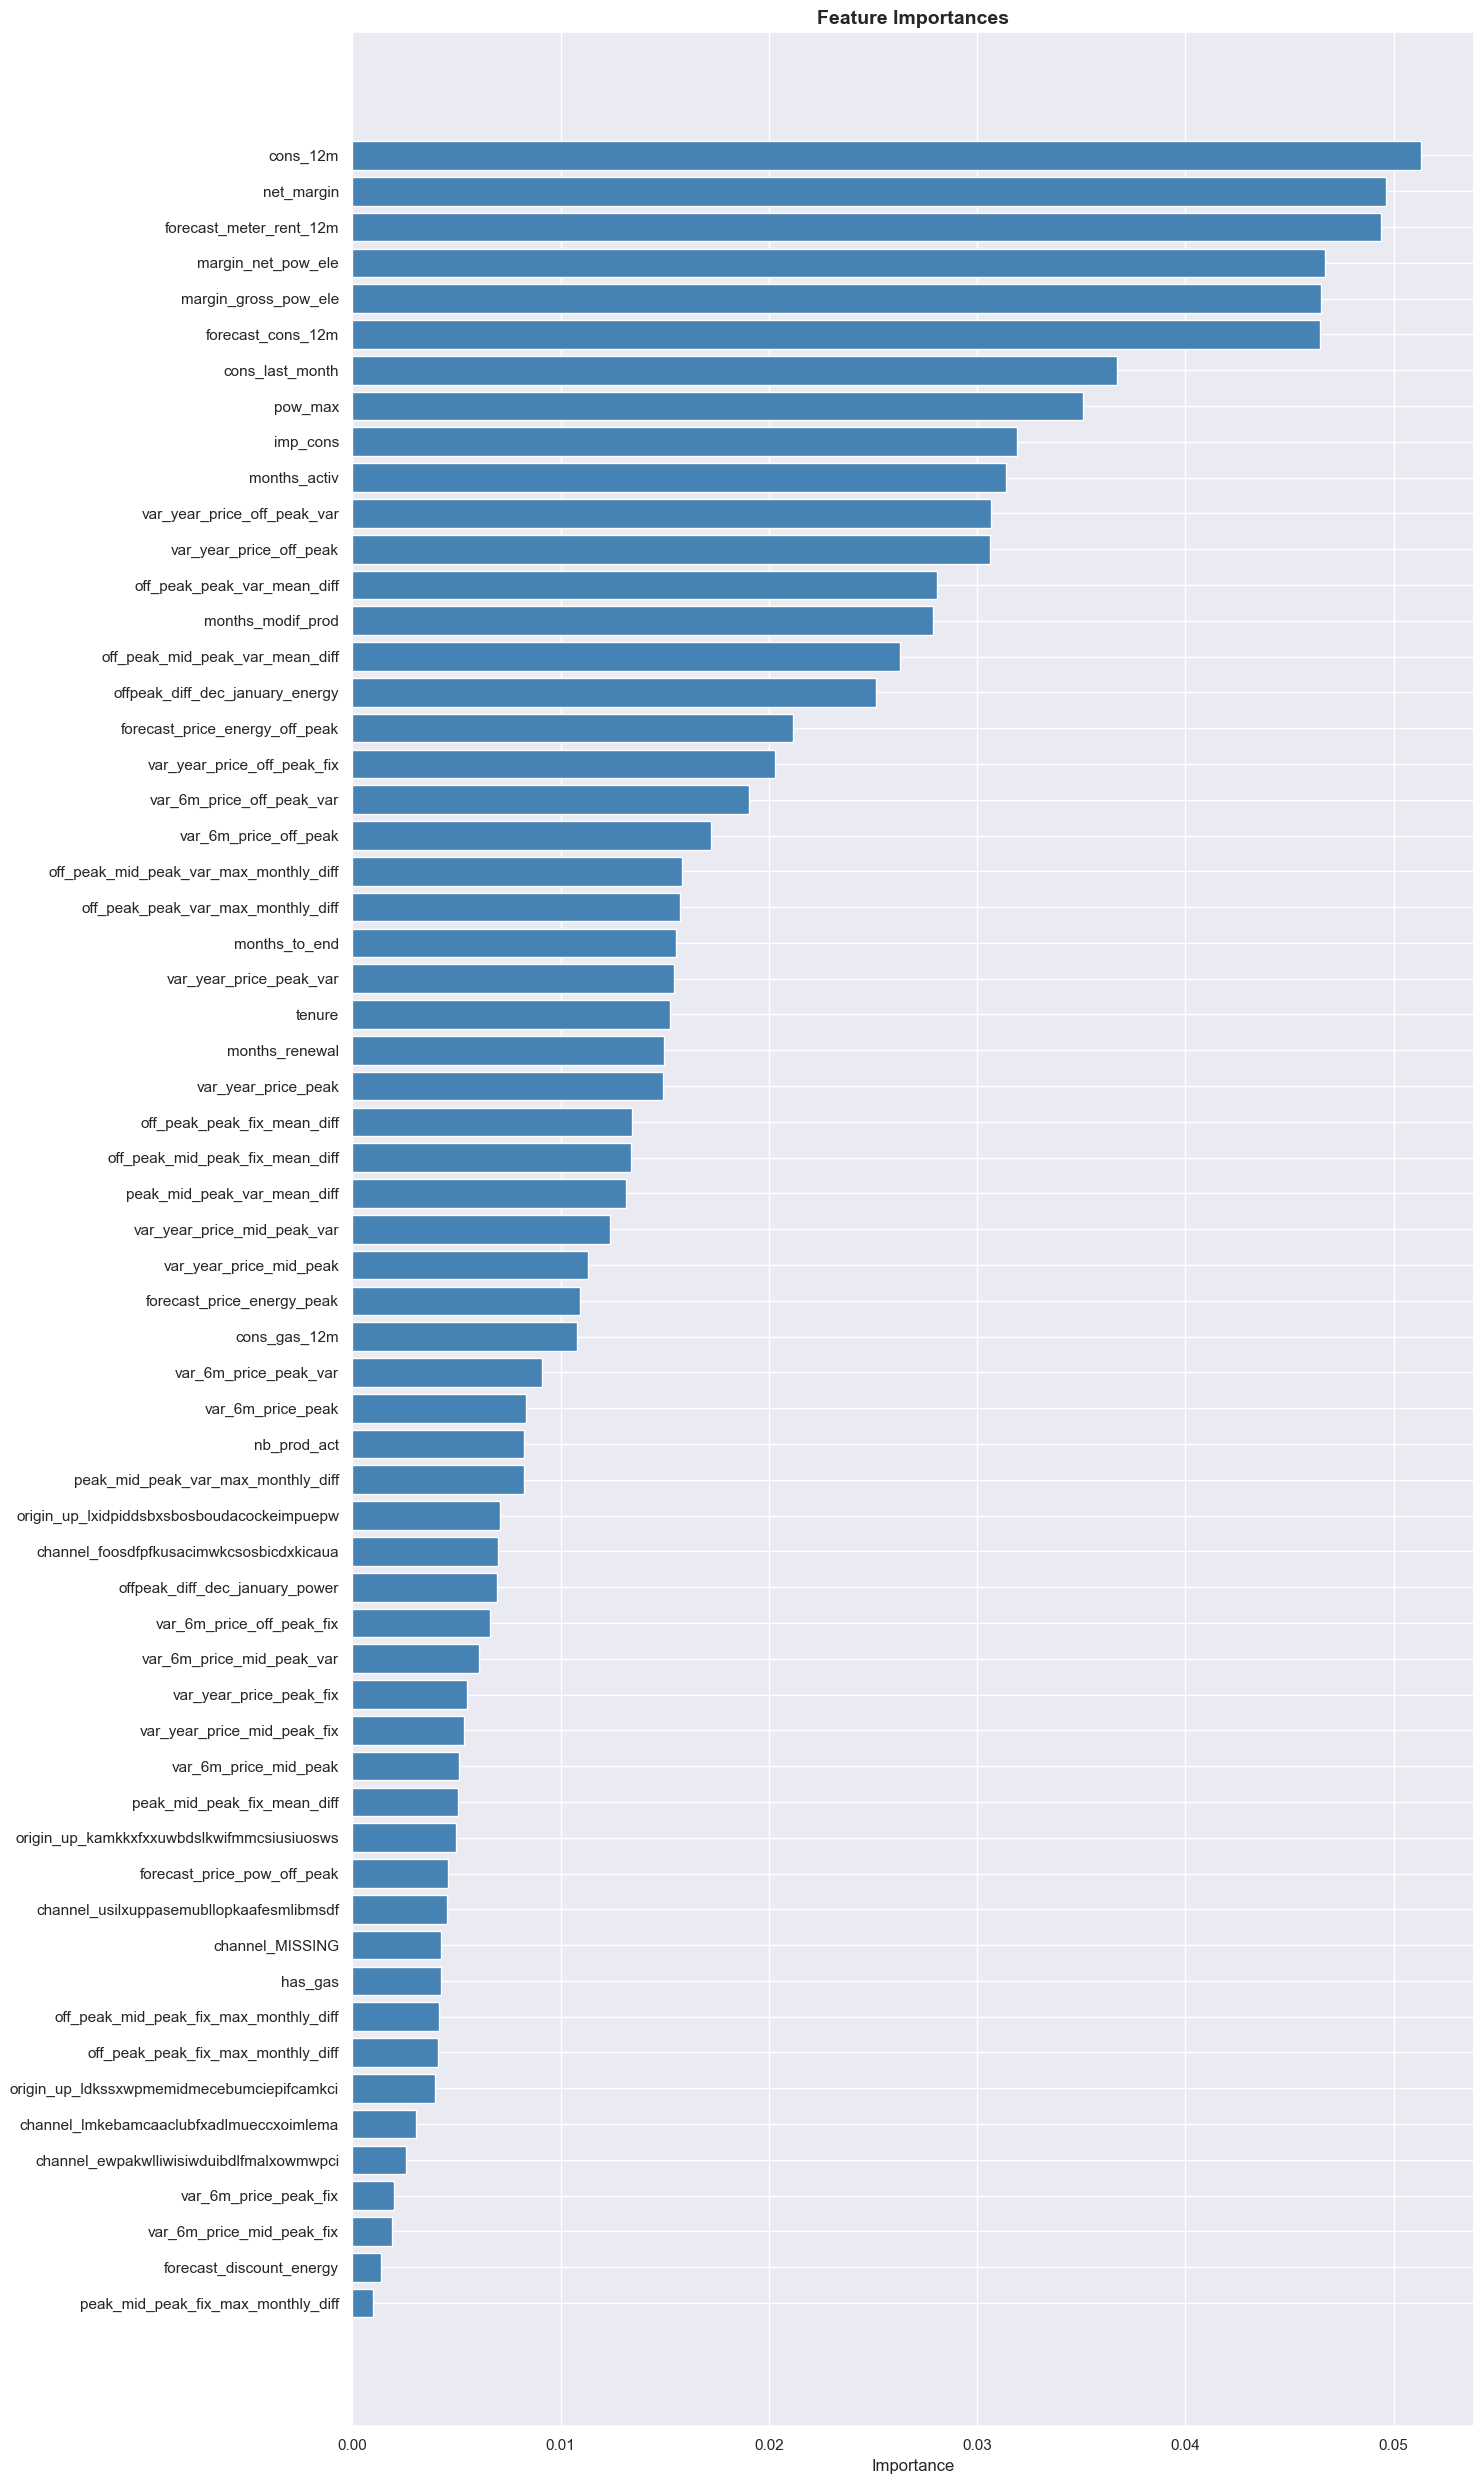

In [11]:
feature_importances = pd.DataFrame({
    'features':   X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=True).reset_index(drop=True)

plt.figure(figsize=(15, 25))
plt.title('Feature Importances', fontsize=14, fontweight='bold')
plt.barh(range(len(feature_importances)), feature_importances['importance'],
         color='steelblue', align='center')
plt.yticks(range(len(feature_importances)), feature_importances['features'])
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [12]:
print('=== KEY FINDINGS FROM FEATURE IMPORTANCES ===')
top10 = feature_importances.tail(10)[::-1]
print('\nTop 10 most important features:')
for _, row in top10.iterrows():
    print(f'  {row["features"]:<45} {row["importance"]:.4f}')

print()
print('► Net margin and consumption over 12 months are the TOP drivers of churn.')
print('  Customers with low margin or unusual consumption patterns are most at risk.')
print()
print('► Time-based features (months_activ, tenure, months_modif_prod) rank highly.')
print('  Contract lifecycle stage matters a great deal.')
print()
print('► Price sensitivity features (off-peak diff features) are present but do NOT dominate.')
print('  This is important: price is NOT the primary driver of churn in its current form.')
print()
print('► This challenges the original hypothesis but does not rule out price sensitivity.')
print('  More feature engineering on price (e.g. individual rate trends) may surface stronger signals.')

=== KEY FINDINGS FROM FEATURE IMPORTANCES ===

Top 10 most important features:
  cons_12m                                      0.0513
  net_margin                                    0.0497
  forecast_meter_rent_12m                       0.0494
  margin_net_pow_ele                            0.0467
  margin_gross_pow_ele                          0.0465
  forecast_cons_12m                             0.0465
  cons_last_month                               0.0367
  pow_max                                       0.0351
  imp_cons                                      0.0319
  months_activ                                  0.0314

► Net margin and consumption over 12 months are the TOP drivers of churn.
  Customers with low margin or unusual consumption patterns are most at risk.

► Time-based features (months_activ, tenure, months_modif_prod) rank highly.
  Contract lifecycle stage matters a great deal.

► Price sensitivity features (off-peak diff features) are present but do NOT dominate.
  T

### Export Predictions

We attach churn predictions and probability scores to the test set and export for downstream use (e.g. targeting high-risk customers for the 20% discount retention campaign).

In [13]:
proba_predictions = model.predict_proba(X_test)
probabilities     = proba_predictions[:, 1]   # probability of churn

X_test_out = X_test.reset_index(drop=True).copy()
X_test_out['churn']             = predictions.tolist()
X_test_out['churn_probability'] = probabilities.tolist()

OUTPUT_PATH = './out_of_sample_data_with_predictions.csv'
X_test_out.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Predictions saved to: {OUTPUT_PATH}')
print(f'   Customers predicted to churn : {int(X_test_out["churn"].sum())}')
print(f'   Total test customers         : {len(X_test_out):,}')
print()
print('Top 10 highest risk customers:')
print(X_test_out.nlargest(10, 'churn_probability')[['churn', 'churn_probability']])

✅ Predictions saved to: ./out_of_sample_data_with_predictions.csv
   Customers predicted to churn : 21
   Total test customers         : 3,652

Top 10 highest risk customers:
      churn  churn_probability
1383      1              0.985
158       1              0.978
1833      1              0.977
355       1              0.900
1252      1              0.864
2570      1              0.848
917       1              0.827
3273      1              0.812
1536      1              0.788
2526      1              0.749


## ✅ Modelling Complete

| Result | Value |
|---|---|
| Algorithm | Random Forest (1,000 trees) |
| Split | 75% train / 25% test |
| Accuracy | ~90% (misleading due to class imbalance) |
| Precision | ~81% (when we flag a churner, we are usually right) |
| Recall | ~5% (main weakness — most churners are missed) |
| Top drivers | Net margin, 12-month consumption, contract tenure |
| Price sensitivity | Present but not a primary driver |

### Recommended Next Steps

1. **Fix Task 4** — log-transform was applied in this run; verify `data_for_predictions.csv` is up to date.
2. **`class_weight='balanced'`** in `RandomForestClassifier` — will significantly boost recall.
3. **Threshold tuning** — use `predict_proba` to find a decision threshold that balances precision/recall for the business cost of each error type.
4. **Report ROC-AUC and F1-score** — more informative than accuracy for imbalanced binary classification.
5. **Cross-validation** — use `StratifiedKFold` to get reliable metric estimates across multiple splits.